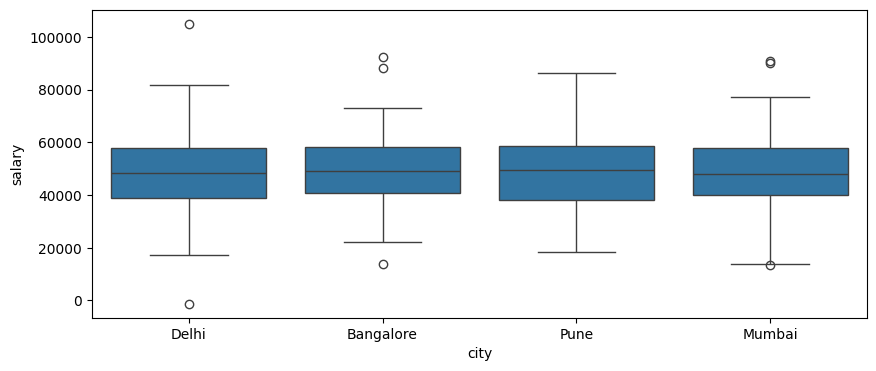

R2 Score: -0.10
MSE: 210.19


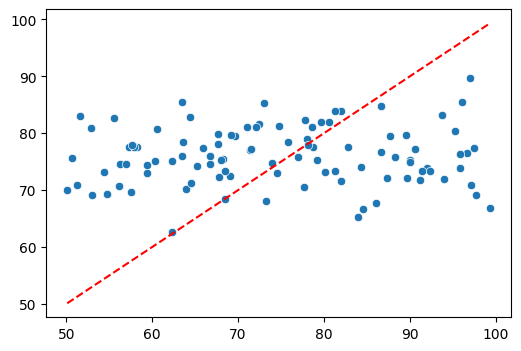

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score

df = pl.DataFrame({
    "age": np.random.randint(18, 65, 500),
    "salary": np.random.normal(50000, 15000, 500),
    "experience": np.random.randint(0, 30, 500),
    "city": np.random.choice(["Delhi", "Mumbai", "Pune", "Bangalore"], 500),
    "performance_score": np.random.uniform(50, 100, 500)
})

df = df.with_columns(pl.col("salary").fill_null(pl.col("salary").median()))
df = df.with_columns((pl.col("salary") / (pl.col("experience") + 1)).alias("salary_per_year"))

plt.figure(figsize=(10, 4))
sns.boxplot(data=df.to_pandas(), x="city", y="salary")
plt.show()

X = df.drop("performance_score").to_pandas()
y = df["performance_score"].to_numpy()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ["age", "salary", "experience", "salary_per_year"]),
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["city"])
    ]
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=100, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline.fit(X_train, y_train)
preds = pipeline.predict(X_test)

print(f"R2 Score: {r2_score(y_test, preds):.2f}")
print(f"MSE: {mean_squared_error(y_test, preds):.2f}")

plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_test, y=preds)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()